In [1]:
import itertools

import numpy as np
import astropy.units as u
from astropy.units import Quantity
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.time import Time
import pandas as pd
from sparse import COO
import h5py

from lmfit.lineshapes import gaussian

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from pathlib import Path

from cosipy.response import FullDetectorResponse, DetectorResponse, PointSourceResponse
from FullDetectorResponseNew import FullDetectorResponse
from DetectorResponseNew import DetectorResponse
from cosipy.spacecraftfile import SpacecraftFile
from cosipy import test_data

from histpy import Histogram, Axes, Axis, HealpixAxis
import mhealpy as hp
from mhealpy import HealpixMap, HealpixBase
from scoords import Attitude, SpacecraftFrame

from threeML import Model, Powerlaw, Gaussian

13:12:08 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=984534;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=403081;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=101037;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=798313;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=369175;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=290060;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=953809;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=305945;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

13:12:10 WARNING   No fermitools installed                                              ]8;id=532237;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=629272;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

13:12:10 WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=506295;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=550605;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=977261;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=663714;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=610571;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=496257;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
# image_response = Histogram.open('reparam_spectral_response_example.h5')

# dr = DetectorResponse(edges = image_response.axes[1:],
#                       contents = image_response.slice[1].contents.reshape(5,5),
#                       sparse = False,
#                       unit = image_response.unit,
#                       coord = None)

In [3]:
DATA_DIR = Path('/Users/penguin/Documents/Grad School/Research/COSI/COSIpy/docs/DC3/')
response_path = DATA_DIR / 'data/responses/DC2-Continuum_N-149_17-11-2024_14-32.imagingresponse_nside8.area.h5'

In [4]:
pix = 0

with FullDetectorResponse.open(response_path) as f:
    print(f.__dict__)
    nside = f.nside
    # print(f._axes['NuLambda'].edges)
    dr = f[pix]

{'_file': <HDF5 file "DC2-Continuum_N-149_17-11-2024_14-32.imagingresponse_nside8.area.h5" (mode r)>, '_drm': <HDF5 group "/DRM" (3 members)>, '_unit': Unit("cm2"), '_sparse': True, '_axes': <histpy.axes.Axes object at 0x103cb3bb0>, '_pix_rangesets': None, '_pix_rangesets_argsort': None, '_uniq': None, '_scheme': 'RING', '_order': 3, '_coordsys': <SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>, '_npix_ratio_max': 4503599627370496}


In [6]:
def get_vector(Phi_sc, Theta_sc):
    """
    Construct a 3D vector from sine-cosine representations of angular coordinates using NumPy arrays.

    The inputs, Phi_sc and Theta_sc, are expected to be produced by '_sc_stacker', so that each
    contains both the sine and cosine values of the corresponding angle.

    Parameters:
        Phi_sc (ndarray): Sine-cosine representation of the phi angle.
        Theta_sc (ndarray): Sine-cosine representation of the theta angle.

    Returns:
        ndarray: A 3D vector computed from the provided sine-cosine components.
    """
    x = Theta_sc[0] * Phi_sc[1]
    y = Theta_sc[0] * Phi_sc[0]
    z = Theta_sc[1]

    return np.stack((x, y, z), axis=-1)

def sc_stacker(t):
    """
    Create a sine-cosine NumPy array from an angle.

    Parameters:
        t (ndarray): A NumPy array of angles.

    Returns:
        ndarray: A vertically stacked array containing [sin(t), cos(t)] ("sine-cosine representation").
    """
    return np.vstack((np.sin(t), np.cos(t)))

def pix_to_ang(pix, nside=nside):
    # Added code to convert healpy pixel to angles in radians
    NuLambda_sc = np.atleast_1d(pix)
    Nu_sc, Lambda_sc = hp.pix2ang(nside=nside, ipix=NuLambda_sc)
    Nu_sc = sc_stacker(Nu_sc)
    Lambda_sc = sc_stacker(Lambda_sc)

    return (Nu_sc, Lambda_sc)

def convert_conventions(NuLambda_sc, Ei, Em, Phi, Psi_sc, Chi_sc):
    """
    Convert classical to relative coordinate convention.
    
    Parameters:
        NuLambda_sc (ndarray): Healpix representation of the initial photon direction in spacecraft coordinates.
        Ei (ndarray): Initial energy.
        Em (ndarray): Measured energy.
        Phi (ndarray): Scattering angle.
        Psi_sc, Chi_sc (ndarray): Angular representation (radians) of the scattering direction in spacecraft coordinates.
        
    Returns:
        tuple: (Epsilon, Theta ARM, Zeta) in relative coordinates
    """
    Eps = Em/Ei - 1

    # Data preprocessing
    Nu_sc, Lambda_sc = pix_to_ang(NuLambda_sc)
    Psi_sc = sc_stacker(Psi_sc)
    Chi_sc = sc_stacker(Chi_sc)

    source = get_vector(Nu_sc, Lambda_sc)
    scatter = get_vector(Psi_sc, Chi_sc)

    Phi_geo = np.arccos(np.clip(np.sum(source * scatter, axis=1), -1., 1.))     # np.arccos input range is -1 to +1

    xaxis = np.array([1., 0., 0.], dtype=source.dtype)
    pz = -source
    px = np.cross(pz, np.broadcast_to(xaxis, pz.shape), axis=1)
    px /= np.linalg.norm(px, axis=1, keepdims=True)
    py = np.cross(pz, px, axis=1)
    py /= np.linalg.norm(py, axis=1, keepdims=True)

    proj_x = np.sum(scatter * px, axis=1)
    proj_y = np.sum(scatter * py, axis=1)

    Zeta = np.arctan2(proj_y, proj_x)
    Zeta = np.where(Zeta < 0, Zeta + 2*np.pi, Zeta)

    return (Eps, Phi_geo - Phi, Zeta)
    # return (Phi_geo - Phi, Zeta)

def reverse_conventions(NuLambda_sc, Ei, Eps, Phi, Theta, Zeta):
    """
    Convert relative to classical coordinate convention using NumPy arrays.
    
    Parameters:
        NuLambda_sc (ndarray): Healpix representation of the initial photon direction in spacecraft coordinates.
        Ei (ndarray): Initial energy.
        Eps (ndarray): Relative measured energy.
        Phi (ndarray): Scattering angle.
        Theta, Zeta (ndarray): Angular representation (radians) of the scattering direction in relative spacecraft coordinates.
        
    Returns:
        tuple: (Em, Psi, Chi) in classical coordinates
    """
    Em = Ei * (Eps + 1)

    Psi_sc = sc_stacker(Zeta)
    Chi_sc = sc_stacker(np.pi - (Theta + Phi))
    scatter_base = get_vector(Psi_sc, Chi_sc)

    # Data preprocessing
    Nu_sc, Lambda_sc = pix_to_ang(NuLambda_sc)

    source = get_vector(Nu_sc, Lambda_sc)
    xaxis = np.array([1., 0., 0.], dtype=source.dtype)
    pz = -source
    px = np.cross(pz, np.broadcast_to(xaxis, pz.shape), axis=1)
    px /= np.linalg.norm(px, axis=1, keepdims=True)
    py = np.cross(pz, px, axis=1)
    py /= np.linalg.norm(py, axis=1, keepdims=True)

    change_basis = np.stack((px, py, pz), axis=2)
    scatter = np.matmul(change_basis, scatter_base[..., np.newaxis]).squeeze(-1)
    scatter /= np.linalg.norm(scatter, axis=1, keepdims=True)

    Psi = np.arctan2(scatter[:, 1], scatter[:, 0])
    Psi = np.where(Psi < 0, Psi + 2*np.pi, Psi)

    Chi = np.arccos(np.clip(scatter[:, 2], -1., 1.))        # np.arccos input range is -1 to +1

    return (Em, Psi, Chi)
    # return (Psi, Chi)

In [7]:
NuLambda_sc = np.array([0])
Ei = 511
Eps = -0.002
Phi = np.deg2rad(30)
Theta = np.deg2rad(15)
Zeta = np.deg2rad(10)

print(Eps, Theta, Zeta)

Em, Psi_sc, Chi_sc = reverse_conventions(NuLambda_sc, Ei, Eps, Phi, Theta, Zeta)
convert_conventions(NuLambda_sc, Ei, Em, Phi, Psi_sc, Chi_sc)

-0.002 0.2617993877991494 0.17453292519943295


(-0.0020000000000000018, array([0.26179939]), array([0.17453293]))

In [ ]:
def get_all_interp_weights(dr, target: dict):
    indices = []
    weights = []

    
    for key in ['Ei', 'Em', 'Phi', 'PsiChi']:

        if key == 'Ei':
            label = key

        elif key == 'Em':
            label = 'Eps'

        elif key == 'Phi':
            label = key

        elif key == 'PsiChi':
            # label = 'ThetaZeta'
            axis_type = 'Axis'      # Theta, Zeta have axis_type = 'Axis'. PsiChi axis_type = 'HealpixAxis'

            NuLambda_sc = np.array([0])         # Placeholder. FullDetectorResponse object depends on NuLambda. Detector Response object does not. 
            # I/O with radians not degrees
            _, Theta, Zeta = convert_conventions(NuLambda_sc, target['Ei'], target['Em'], target['Phi'].to(u.rad).value, \
                                                 target['Psi_sc'].to(u.rad).value, target['Chi_sc'].to(u.rad).value)        # target['Ei', 'Em'] do not matter as we are throwing away the spectral component returned bu the function. 
            
            Theta = Theta * u.rad
            Zeta = Zeta * u.rad
            print(Theta, Zeta)

            # Theta axis
            idx, w = dr.axes['Theta'].interp_weights(Theta)
            indices.append(idx.reshape(-1))
            weights.append(w.reshape(-1))

            # Zeta axis
            idx, w = dr.axes['Zeta'].interp_weights(Zeta)
            indices.append(idx.reshape(-1))
            weights.append(w.reshape(-1))

            continue
        
        axis = dr.axes[label]

        axis_scale = axis._scale
        axis_type = str(type(axis)).split('.')[-1].strip("'>")      # XXX: Could probably be simplified using `isinstance()`

        # Scale
        if axis_scale in ['linear', 'log']:   # To ensure nonlinear binning parametrizations are converted to a linear scale.

            # Axis Type
            if axis_type in ['Axis', 'HealpixAxis']:

                if key == 'Ei':
                    idx, w = axis.interp_weights(target[key])

                elif key == 'Em':
                    centers = dr.transform_Eps_to_Em(axis.centers, target['Ei'])      # Transform coordinates to more physical units      # TODO: Generalize this
                    absdiff = np.abs(centers - target[key])                             # Calculate absolute difference to given target
                    idx = np.argpartition(absdiff, (1,2))[:2]                               # Find indices corresponding to two smallest absdiff
                    w = 1 - np.partition(absdiff, (1,2))[:2] / (centers[1] - centers[0])    # Calculate weights corresponding to two smallest absdiff

                elif key == 'Phi':
                    idx, w = axis.interp_weights(target[key])

            else:
                raise ValueError(f'Axis type: {axis_type} is not supported')

        else:
            raise ValueError(f'{axis_scale} binning / scale scheme is not supported')
        
        indices.append(idx)
        weights.append(w)
    
    return (indices, weights)

def get_interp_response(dr, target: dict):
    """
    Currently only supports nonlinear spectral responses (
    and for a particular parametrization)
    TODO: In the future, this will also support nonlinear / 
    piecewise-linear directional responses.
    """

    # target = dict(sorted(target.items()))       # Sort dictionary by key (XXX: assuming response matrix also sorts in the same way)
    indices, weights = get_all_interp_weights(dr, target)
    print(indices, weights)
    perm_indices = list(itertools.product(*indices))
    perm_weights = list(itertools.product(*weights))

    if len(target) == len(dr.axes):
        interpolated_response_value = 0
        for idx, w in zip(perm_indices, perm_weights):
            interpolated_response_value += np.prod(w) * dr.contents[idx]

    else:
        raise ValueError('len(target) != len(dr.axes)')
    
    return interpolated_response_value

In [132]:
convert_conventions(NuLambda_sc, target['Ei'], target['Em'], target['Phi'].to(u.rad).value, target['Psi_sc'].to(u.rad).value, target['Chi_sc'].to(u.rad).value)

(<Quantity 0.>, array([1.3241261]), array([3.07001578]))

In [171]:
Ei0 = 511 * u.keV #505.11474*u.keV
Em0 = 511 * u.keV #505.11474*u.keV
Phi0 = 20 * u.deg
Psi_sc0 = 77.5 * u.deg
Chi_sc0 = 90 * u.deg
# for Psi_sc0 in np.arange(70, 110)*u.deg:
target = {'Ei': Ei0, 'Em': Em0, 'Phi': Phi0}
target = {'Ei': Ei0, 'Em': Em0, 'Phi': Phi0, 'Psi_sc': Psi_sc0, 'Chi_sc': Chi_sc0}

hist = dr.project('Ei', 'Eps', 'Phi')
hist = dr.project('Ei', 'Eps', 'Phi', 'Theta', 'Zeta')
dr2 = DetectorResponse(coord = dr.coord, edges=hist.axes, contents=hist.contents, unit=dr.unit)
print(Psi_sc0, get_interp_response(dr2, target))
# plt.imshow(get_interp_response(dr2, target).todense())

[0.99723441] rad [3.22806758] rad
[array([33, 34]), array([90, 89]), array([ 9, 10]), array([117, 118]), array([91, 92])] [array([0.90105938, 0.09894062]), <Quantity [0.4999955, 0.4999955]>, array([0.61110012, 0.38889988]), array([0.5900489, 0.4099511]), array([0.53647536, 0.46352464])]
77.5 deg 7.928606358320494e-05


In [10]:
Ei0 = 505.11474*u.keV
Em0 = (1 - 0.00555555) * 505.11474*u.keV
Phi0 = 10 * u.deg
target = {'Ei': Ei0, 'Em': Em0, 'Phi': Phi0}

get_all_interp_weights(dr, target)

([array([32, 33]), array([89, 90]), array([4, 5])],
 [array([8.08905678e-08, 9.99999919e-01]),
  <Quantity [ 1.00000e+00, -9.00009e-06]>,
  array([0.55556242, 0.44443758])])

In [11]:
dr.axes['Eps'].centers

<Quantity [-0.9944445 , -0.9833335 , -0.9722225 , -0.9611115 , -0.95      ,
           -0.9388885 , -0.9277775 , -0.9166665 , -0.9055555 , -0.8944445 ,
           -0.8833335 , -0.8722225 , -0.8611115 , -0.85      , -0.8388885 ,
           -0.8277775 , -0.8166665 , -0.8055555 , -0.7944445 , -0.7833335 ,
           -0.7722225 , -0.7611115 , -0.75      , -0.7388885 , -0.7277775 ,
           -0.7166665 , -0.7055555 , -0.6944445 , -0.6833335 , -0.6722225 ,
           -0.6611115 , -0.65      , -0.6388885 , -0.6277775 , -0.6166665 ,
           -0.6055555 , -0.5944445 , -0.5833335 , -0.5722225 , -0.5611115 ,
           -0.55      , -0.5388885 , -0.5277775 , -0.5166665 , -0.5055555 ,
           -0.4944445 , -0.4833335 , -0.4722225 , -0.4611115 , -0.45      ,
           -0.4388885 , -0.4277775 , -0.4166665 , -0.4055555 , -0.3944445 ,
           -0.3833335 , -0.3722225 , -0.3611115 , -0.35      , -0.3388885 ,
           -0.3277775 , -0.3166665 , -0.3055555 , -0.2944445 , -0.2833335 ,
           -

In [13]:
dr.get_effective_area(400*u.keV)

<Quantity 104.2147474 cm2>

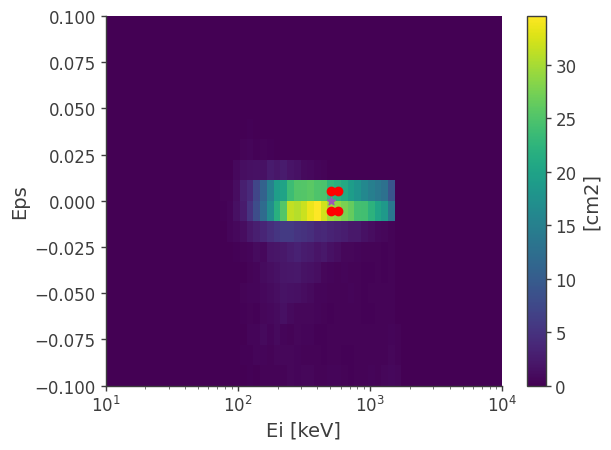

In [25]:
fig, ax = plt.subplots()
dr.project('Ei', 'Eps').draw(ax=ax)
ax.scatter(Ei0, dr.transform_Em_to_Eps(Em0, Ei0), marker='*')

target = {'Ei': Ei0, 'Em': Em0}
hist = dr.project('Ei', 'Eps')
dr2 = DetectorResponse(coord = dr.coord, edges=hist.axes, contents=hist.contents, unit=dr.unit)
dr2.get_interp_response(target)

for e1 in dr2.neighbors['Ei']:
    for e2 in dr2.neighbors['Eps']:
        ax.scatter(e1, e2, c='r')

ax.set_ylim([-0.1, 0.1])
plt.show()

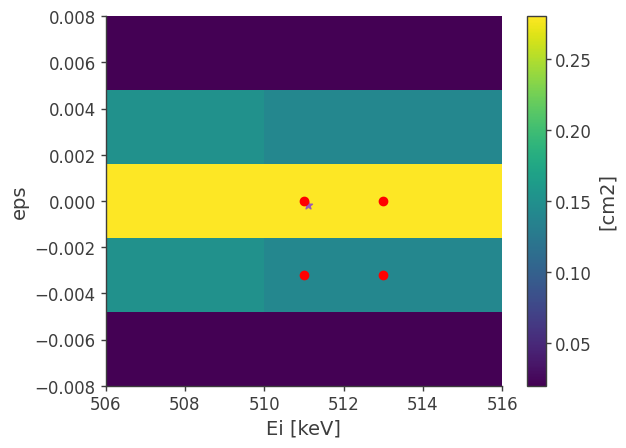

In [ ]:
fig, ax = plt.subplots()
dr.project('Ei', 'Eps').draw(ax=ax)
ax.scatter(Ei0, dr.transform_Em_to_Eps(Em0, Ei0), marker='*')
for e1 in dr.neighbors['Ei']:
    for e2 in dr.neighbors['eps']:
        ax.scatter(e1, e2, c='r')
plt.show()

### PyTorch versions

In [ ]:
import torch

In [ ]:
NuLambda_sc = torch.tensor([100])
Nu_sc, Lambda_sc = hp.pix2ang(nside=nside, ipix=NuLambda_sc)
Nu_sc = _sc_stacker(Nu_sc).to(torch.float32)
Lambda_sc = _sc_stacker(Lambda_sc).to(torch.float32)

Ei = 511
Eps = -0.002
Phi = torch.tensor(np.deg2rad(30, dtype=np.float32))
Theta = torch.tensor(np.deg2rad(15, dtype=np.float32))
Zeta = torch.tensor(np.deg2rad(10, dtype=np.float32))

Em, Psi_sc, Chi_sc = _reverse_conventions(Nu_sc, Lambda_sc, Ei, Eps, Phi, Theta, Zeta)
# print(Em, Psi_sc, Chi_sc)
Psi_sc = _sc_stacker(Psi_sc)
Chi_sc = _sc_stacker(Chi_sc)
_convert_conventions(Nu_sc, Lambda_sc, Ei, Em, Phi, Psi_sc, Chi_sc)

(-0.0020000000000000018, tensor([0.2618]), tensor([0.1745]))

In [ ]:
def _get_vector(Phi_sc, Theta_sc):
    """
    Construct a 3D vector from sine-cosine representations of angular coordinates.

    The inputs, Phi_sc and Theta_sc, are expected to be produced by '_sc_stacker', so that each
    contains both the sine and cosine values of the corresponding angle.

    Parameters:
        Phi_sc (Tensor): Sine-cosine representation of the phi angle.
        Theta_sc (Tensor): Sine-cosine representation of the theta angle.

    Returns:
        Tensor: A 3D vector computed from the provided sine-cosine components.
    """
    x = Theta_sc[0] * Phi_sc[1]
    y = Theta_sc[0] * Phi_sc[0]
    z = Theta_sc[1]

    return torch.stack((x, y, z), dim=-1)

def _sc_stacker(t):
    """
    Create a sine-cosine tensor from an angle.

    Parameters:
        t (Tensor): A tensor of angles.

    Returns:
        Tensor: A vertically stacked tensor containing [sin(t), cos(t)].
    """
    return torch.vstack((torch.sin(t), torch.cos(t)))

def _convert_conventions(Nu_sc, Lambda_sc, Ei, Em, Phi, Psi_sc, Chi_sc):
    """
    Convert classical to relative coordinate convention.
    
    Parameters:
        Nu_sc, Lambda_sc (Tensor): Sine-cosine representation of the initial photon direction in spacecraft coordinates.
        Ei (Tensor): Initial energy.
        Em (Tensor): Measured energy.
        Phi (Tensor): Scattering angle.
        Psi_sc, Chi_sc (Tensor): Sine-cosine representation of the scattering direction in spacecraft coordinates.
        
    Returns:
        tuple: (Epsilon, Theta ARM, Zeta) in relative coordinates
    """
    Eps = Em/Ei - 1

    source = _get_vector(Nu_sc, Lambda_sc)
    scatter = _get_vector(Psi_sc, Chi_sc)

    Phi_geo = torch.arccos(torch.clip(torch.sum(source * scatter, axis=1), -1., 1.))

    xaxis = torch.tensor([1., 0., 0.], dtype=source.dtype)
    pz = -source
    px = torch.cross(pz, xaxis.expand_as(pz), dim=1)
    px /= torch.norm(px, dim=1, keepdim=True)
    py = torch.cross(pz, px, dim=1)
    py /= torch.norm(py, dim=1, keepdim=True)

    proj_x = torch.sum(scatter * px, dim=1)
    proj_y = torch.sum(scatter * py, dim=1)

    Zeta = torch.atan2(proj_y, proj_x)
    Zeta = torch.where(Zeta < 0, Zeta + 2*np.pi, Zeta)

    return (Eps, Phi_geo - Phi, Zeta)

def _reverse_conventions(Nu_sc, Lambda_sc, Ei, Eps, Phi, Theta, Zeta):
    """
    Convert relative to classical coordinate convention.
    
    Parameters:
        Nu_sc, Lambda_sc (Tensor): Sine-cosine representation of the initial photon direction in spacecraft coordinates.
        Ei (Tensor): Initial energy.
        Eps (Tensor): Relative measured energy.
        Phi (Tensor): Scattering angle.
        Theta, Zeta (Tensor): Relative representation of the scattering direction in spacecraft coordinates.
        
    Returns:
        tuple: (Em, Psi, Chi) in classical coordinates
    """
    Em = Ei * (Eps + 1)

    Psi_sc = _sc_stacker(Zeta)
    Chi_sc = _sc_stacker(np.pi - (Theta + Phi))
    scatter_base = _get_vector(Psi_sc, Chi_sc)

    source = _get_vector(Nu_sc, Lambda_sc)
    xaxis = torch.tensor([1., 0., 0.], dtype=source.dtype)
    pz = -source
    px = torch.cross(pz, xaxis.expand_as(pz), dim=1)
    px /= torch.norm(px, dim=1, keepdim=True)
    py = torch.cross(pz, px, dim=1)
    py /= torch.norm(py, dim=1, keepdim=True)

    change_basis = torch.stack((px, py, pz), dim=2)
    scatter = torch.matmul(change_basis, scatter_base.unsqueeze(-1)).squeeze(-1)
    scatter /= torch.norm(scatter, dim=1, keepdim=True)

    Psi = torch.atan2(scatter[:, 1], scatter[:, 0])
    Psi = torch.where(Psi < 0, Psi + 2*np.pi, Psi)

    Chi = torch.acos(torch.clamp(scatter[:, 2], -1., 1.))

    return (Em, Psi, Chi)